In [5]:
import sys
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import DataLoader

sys.path.append('..')
from Dataset import DocumentDataset
from Losses import MultiClassCrossEntropy, SupConLoss
from Models import EmbeddingModel
from utils import *

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
with open('../config.yaml', 'r') as yaml_file:
    config = yaml.safe_load(yaml_file)

In [13]:
dataset = DocumentDataset(root=f"../{config['data_dir']}")
transforms = A.Compose([
    A.Resize(config['img_size'], config['img_size']),
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])
dataset.albu_transforms = transforms
dataloader = DataLoader(dataset, batch_size=6, shuffle=True, num_workers=config['num_workers'])

In [14]:
batch = next(iter(dataloader))
images, labels, _ = batch

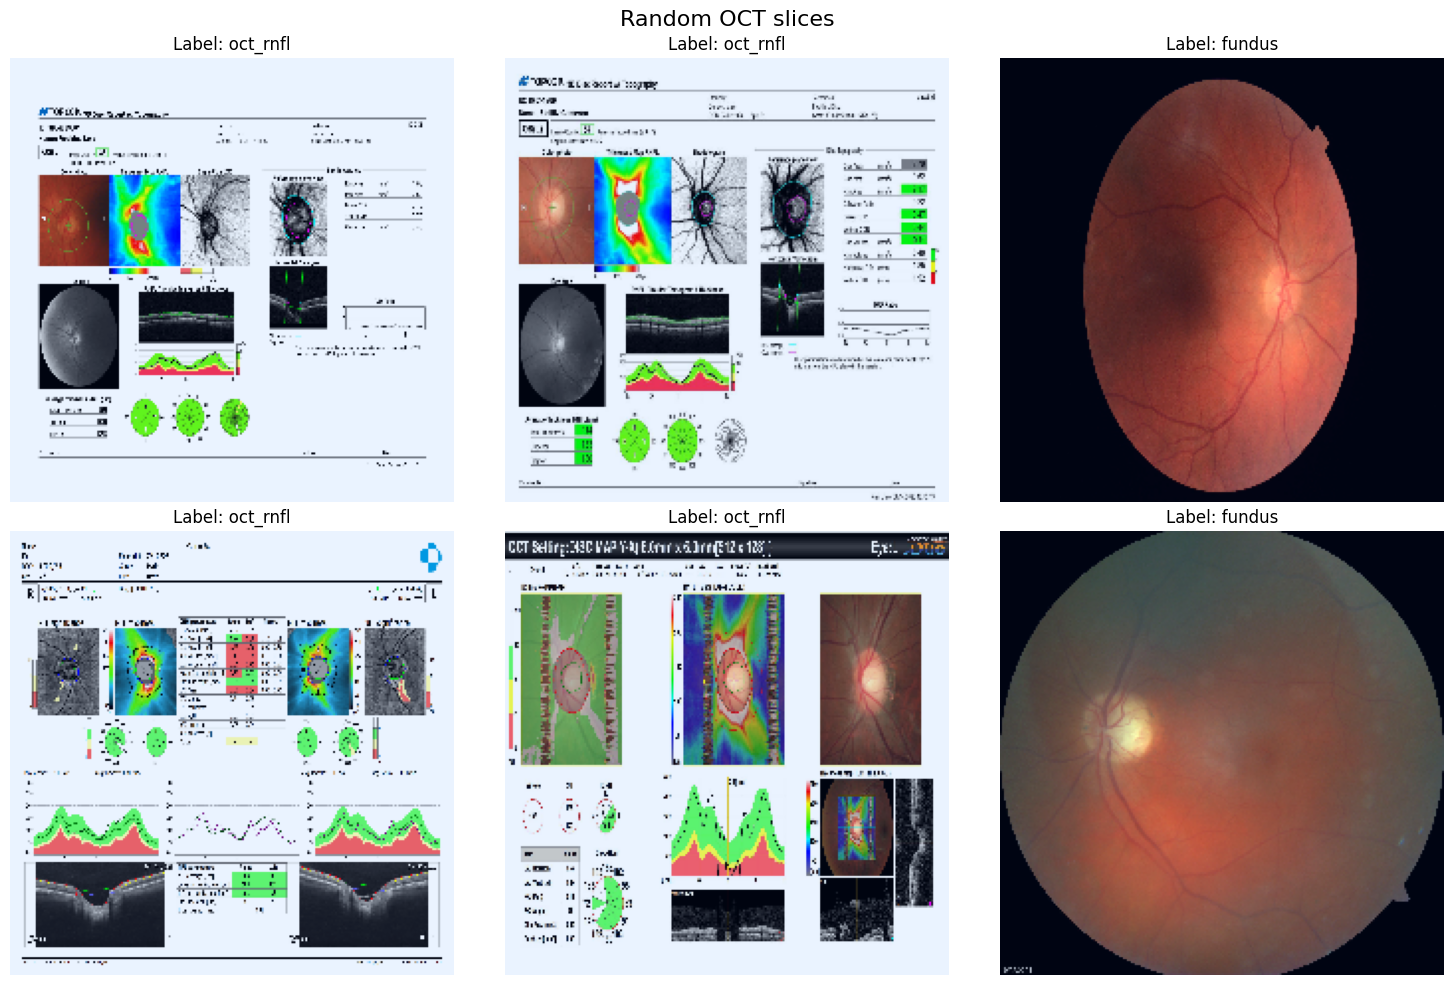

In [15]:
num_images = images.shape[0]
n_cols = min(3, num_images)
n_rows = int(np.ceil(num_images / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i in range(num_images):
    image = images[i].permute(1, 2, 0).cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min())
    image = (image * 255).astype(np.uint8)
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Label: {dataset.classes[labels[i].item()]}')
    axes[i].axis('off')

for j in range(num_images, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"Random OCT slices", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
model = EmbeddingModel(
    backbone_name=config['backbone'],
    embed_dim=config['embed_dim'],
    train_backbone=config['train_backbone'],
    unfreeze_last_n_blocks=config['unfreeze_last_n_blocks'],
    n_classes=config['n_classes'],
    clf_hidden_dim=config['clf_hidden_dim'],
    clf_dropout=config['clf_dropout'],
    clf_return_probs=True,
).to(DEVICE)
model.eval()

In [19]:
embeds, logits, probs = model(images.to(DEVICE))
print("Shapes:", images.shape, embeds.shape, logits.shape, probs.shape)

Shapes: torch.Size([6, 3, 224, 224]) torch.Size([6, 512]) torch.Size([6, 4]) torch.Size([6, 4])


In [21]:
celoss = MultiClassCrossEntropy()
supconloss = SupConLoss()
l_ce = celoss(logits, labels.to(DEVICE))
l_supcon = supconloss(embeds, labels.to(DEVICE))
print("Loss:", (l_ce + l_supcon).item())

Loss: 2.436753273010254
